In [29]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [3]:
df = pd.read_csv("youtube_videos.csv")
df.head()

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,hashtags
0,vid_0000,I tried EVERY transformers tool â€” the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,1193,1091087,287,0.0100,1.3,441016,18.0,"[""ai"", ""tutorial"", ""trending""]"
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,183,423818,1014,0.0230,0.8,25339,17.0,"[""tutorial""]"
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,16119,12952634,587,0.1022,4.8,2398429,NaN,"[""explained""]"
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,1797,2018334,645,0.0413,3.9,498144,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]"
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,30,262565,1252,0.0100,1.3,30039,10.0,"[""explained"", ""shorts""]"


In [4]:
df["subscribers"]

0       441016
1        25339
2      2398429
3       498144
4        30039
        ...   
205      13428
206      10005
207     483919
208      11937
209     553531
Name: subscribers, Length: 210, dtype: int64

In [5]:
df["subscribers"].describe()

count    2.100000e+02
mean     1.005263e+06
std      2.063624e+06
min      5.624000e+03
25%      2.544875e+04
50%      1.359100e+05
75%      4.862028e+05
max      7.763623e+06
Name: subscribers, dtype: float64

In [6]:
scaler = MinMaxScaler()
df["subscribers_minmax"] = scaler.fit_transform(df[["subscribers"]])
df["subscribers_minmax"].describe()

count    210.000000
mean       0.128853
std        0.265999
min        0.000000
25%        0.002555
50%        0.016794
75%        0.061946
max        1.000000
Name: subscribers_minmax, dtype: float64

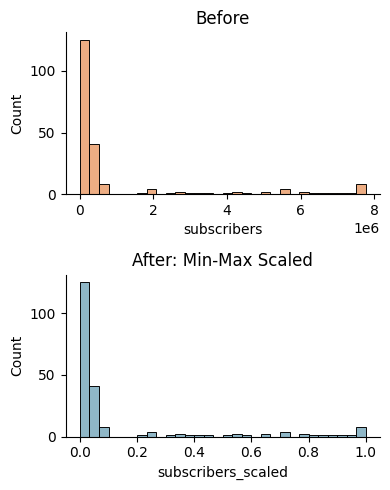

In [9]:
df["subscribers_scaled"] = scaler.fit_transform(
    df[["subscribers"]])
fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["subscribers"], 
             ax=axes[0], 
             color="#e8925a", bins=30)
axes[0].set_title("Before")
axes[0].set_xlabel("subscribers")

sns.histplot(df["subscribers_scaled"], 
             ax=axes[1], 
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Min-Max Scaled")
axes[1].set_xlabel("subscribers_scaled")

sns.despine()
plt.tight_layout()
plt.show()

In [24]:
df.columns

Index(['video_id', 'title', 'category', 'channel_tier', 'upload_day',
       'upload_hour', 'duration_seconds', 'views', 'likes', 'comments',
       'shares', 'watch_time_minutes', 'avg_view_duration_seconds',
       'click_through_rate', 'channel_age_years', 'subscribers', 'tags_count',
       'hashtags', 'subscribers_minmax', 'subscribers_scaled',
       'watch_time_minutes_minmax', 'view_zscore', 'views_scaled',
       'views_robust'],
      dtype='object')

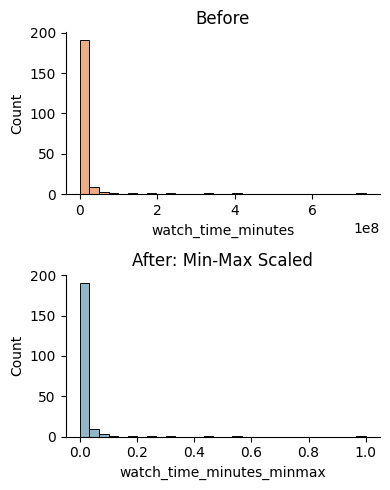

In [12]:
df["watch_time_minutes_minmax"] = scaler.fit_transform(df[["watch_time_minutes"]])

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["watch_time_minutes"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before")
axes[0].set_xlabel("watch_time_minutes")

sns.histplot(df["watch_time_minutes_minmax"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Min-Max Scaled")
axes[1].set_xlabel("watch_time_minutes_minmax")

sns.despine()
plt.tight_layout()
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler

In [18]:
standard_scaler = StandardScaler()
df["view_zscore"] = standard_scaler.fit_transform(df[["views"]])
df[["views", "view_zscore"]].describe()

,views,view_zscore
count,2.100000e+02,2.100000e+02
mean,5.485440e+05,2.537653e-17
std,1.223751e+06,1.002389e+00
min,1.412000e+03,-4.481625e-01
25%,1.080400e+04,-4.404694e-01
50%,6.597350e+04,-3.952794e-01
75%,3.108772e+05,-1.946757e-01
max,7.038551e+06,5.316044e+00


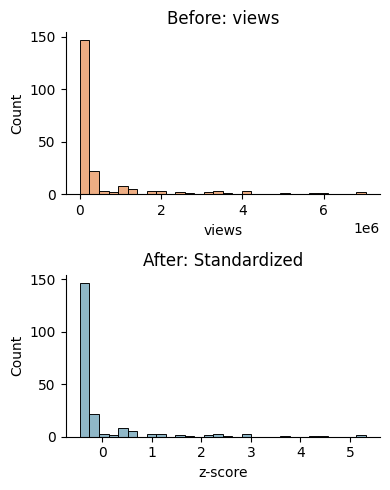

In [20]:
scaler = StandardScaler()
df["views_scaled"] = scaler.fit_transform(df[["views"]])

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["views"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: views")
axes[0].set_xlabel("views")

sns.histplot(df["views_scaled"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Standardized")
axes[1].set_xlabel("z-score")

sns.despine()
plt.tight_layout()
plt.show()

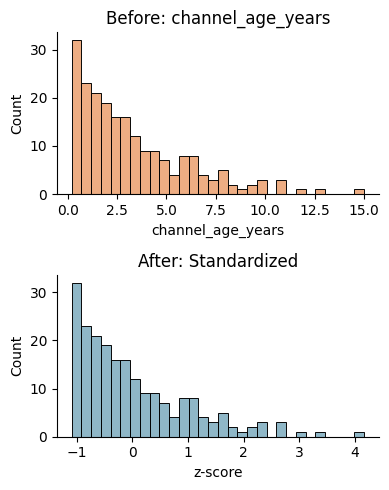

In [26]:
scaler = StandardScaler()
df["channel_age_years_scaled"] = scaler.fit_transform(df[["channel_age_years"]])

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["channel_age_years"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: channel_age_years")
axes[0].set_xlabel("channel_age_years")

sns.histplot(df["channel_age_years_scaled"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Standardized")
axes[1].set_xlabel("z-score")

sns.despine()
plt.tight_layout()
plt.show()

In [21]:
from sklearn.preprocessing import RobustScaler

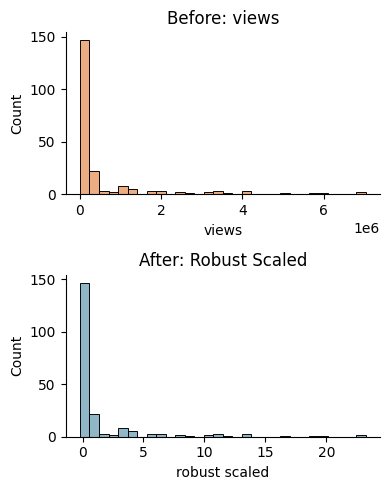

In [23]:
scaler = RobustScaler()
df["views_robust"] = scaler.fit_transform(df[["views"]])

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["views"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: views")
axes[0].set_xlabel("views")

sns.histplot(df["views_robust"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Robust Scaled")
axes[1].set_xlabel("robust scaled")

sns.despine()
plt.tight_layout()
plt.show()

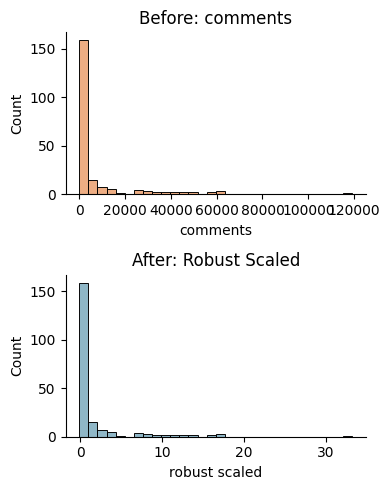

In [27]:
scaler = RobustScaler()
df["comments_robust"] = scaler.fit_transform(df[["comments"]])

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["comments"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: comments")
axes[0].set_xlabel("comments")

sns.histplot(df["comments_robust"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Robust Scaled")
axes[1].set_xlabel("robust scaled")

sns.despine()
plt.tight_layout()
plt.show()

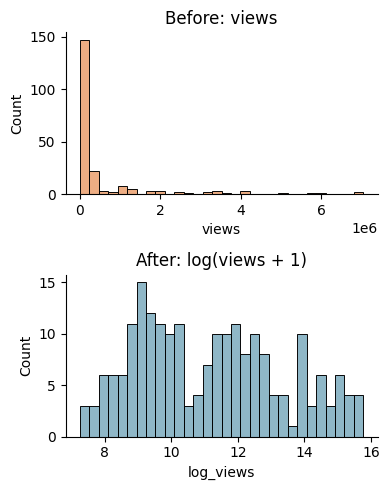

In [30]:
df["log_views"] = np.log1p(df["views"])

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["views"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: views")
axes[0].set_xlabel("views")

sns.histplot(df["log_views"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: log(views + 1)")
axes[1].set_xlabel("log_views")

sns.despine()
plt.tight_layout()

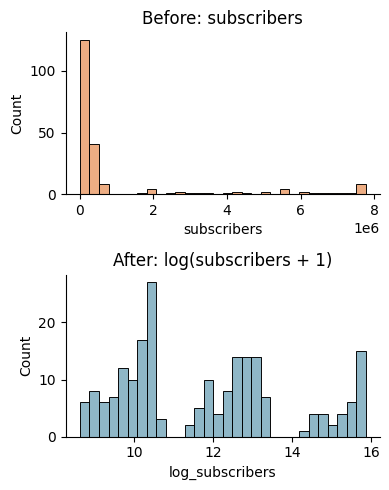

In [31]:
df["log_subscribers"] = np.log1p(df["subscribers"])

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["subscribers"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: subscribers")
axes[0].set_xlabel("subscribers")

sns.histplot(df["log_subscribers"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: log(subscribers + 1)")
axes[1].set_xlabel("log_subscribers")

sns.despine()
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_48900\818591122.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,


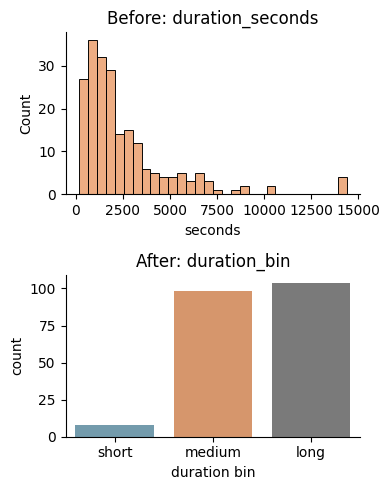

In [32]:
bins = [0, 300, 1800, float("inf")]
labels = ["short", "medium", "long"]

df["duration_bin"] = pd.cut(
    df["duration_seconds"],
    bins=bins,
    labels=labels
)

order = ["short", "medium", "long"]
colors = ["#6a9fb5", "#e8925a", "#7a7a7a"]

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["duration_seconds"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: duration_seconds")
axes[0].set_xlabel("seconds")

sns.countplot(data=df,
              x="duration_bin",
              order=order,
              palette=colors,
              ax=axes[1])
axes[1].set_title("After: duration_bin")
axes[1].set_xlabel("duration bin")
axes[1].set_ylabel("count")

sns.despine()
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_48900\982184716.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,


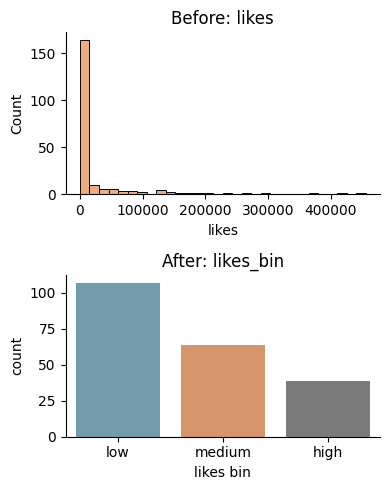

In [34]:
bins = [0, 2500, 25000, float("inf")]
labels = ["low", "medium", "high"]

df["likes_bin"] = pd.cut(
    df["likes"],
    bins=bins,
    labels=labels
)

order = ["low", "medium", "high"]
colors = ["#6a9fb5", "#e8925a", "#7a7a7a"]

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["likes"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: likes")
axes[0].set_xlabel("likes")

sns.countplot(data=df,
              x="likes_bin",
              order=order,
              palette=colors,
              ax=axes[1])
axes[1].set_title("After: likes_bin")
axes[1].set_xlabel("likes bin")
axes[1].set_ylabel("count")

sns.despine()
plt.tight_layout()
plt.show()

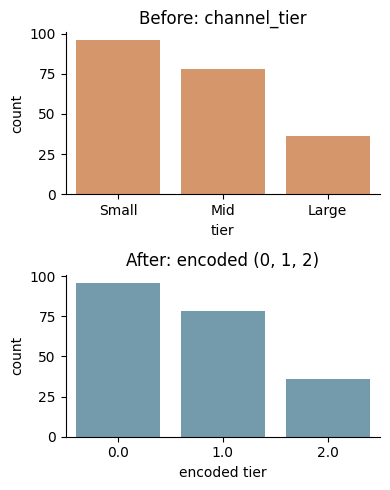

In [36]:
from sklearn.preprocessing import OrdinalEncoder

df = pd.read_csv("youtube_videos.csv")

enc = OrdinalEncoder(categories=[["Small", "Mid", "Large"]])
df["channel_tier_encoded"] = enc.fit_transform(
    df[["channel_tier"]]
)

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

order_str = ["Small", "Mid", "Large"]
sns.countplot(data=df,
              x="channel_tier",
              order=order_str,
              color="#e8925a",
              ax=axes[0])
axes[0].set_title("Before: channel_tier")
axes[0].set_xlabel("tier")

order_num = [0, 1, 2]
sns.countplot(data=df,
              x="channel_tier_encoded",
              color="#6a9fb5",
              ax=axes[1])
axes[1].set_title("After: encoded (0, 1, 2)")
axes[1].set_xlabel("encoded tier")

sns.despine()
plt.tight_layout()
plt.show()

In [37]:
df = pd.read_csv("youtube_videos.csv")

ohe = pd.get_dummies(df["category"], prefix="is")

result = pd.concat([df[["video_id", "category"]], ohe], axis=1)

print(result.head(6).to_string(index=False))

video_id category  is_Comedy  is_Education  is_Gaming  is_Music  is_News  is_Vlog
vid_0000    Music      False         False      False      True    False    False
vid_0001   Gaming      False         False       True     False    False    False
vid_0002   Gaming      False         False       True     False    False    False
vid_0003   Gaming      False         False       True     False    False    False
vid_0004    Music      False         False      False      True    False    False
vid_0005     News      False         False      False     False     True    False


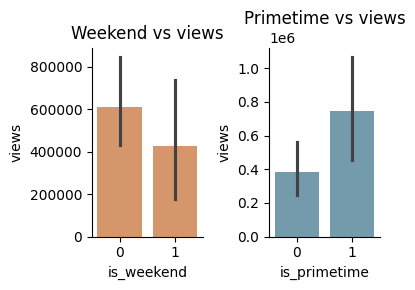

In [38]:
df = pd.read_csv("youtube_videos.csv")

# simulate a full timestamp from existing day/hour columns
day_map = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2,
    "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
}
rng = np.random.default_rng(42)
base = pd.Timestamp("2024-01-01")

df["uploaded_at"] = [
    base
    + pd.offsets.Week(weekday=day_map[d])
    + pd.Timedelta(hours=int(h))
    + pd.Timedelta(minutes=int(rng.integers(0, 60)))
    for d, h in zip(df["upload_day"], df["upload_hour"])
]

# extract features from timestamp
df["is_weekend"] = (df["uploaded_at"].dt.dayofweek >= 5).astype(int)
df["is_primetime"] = (
    (df["uploaded_at"].dt.hour >= 18) &
    (df["uploaded_at"].dt.hour <= 22)
).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(4, 3))

sns.barplot(data=df,
            x="is_weekend",
            y="views",
            color="#e8925a",
            ax=axes[0])
axes[0].set_title("Weekend vs views")
axes[0].set_xlabel("is_weekend")

sns.barplot(data=df,
            x="is_primetime",
            y="views",
            color="#6a9fb5",
            ax=axes[1])
axes[1].set_title("Primetime vs views")
axes[1].set_xlabel("is_primetime")

sns.despine()
plt.tight_layout()
plt.show()

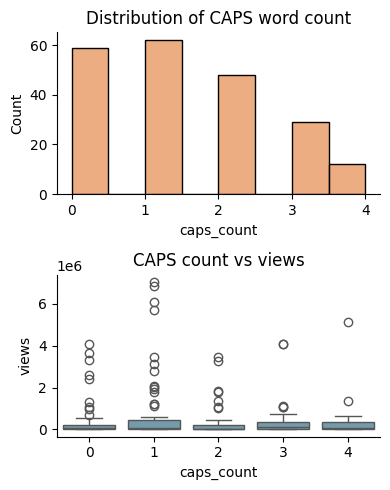

In [39]:
df = pd.read_csv("youtube_videos.csv")

df["caps_count"] = df["title"].apply(
    lambda t: sum(1 for w in t.split() if w.isupper())
)

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["caps_count"],
             bins=8,
             color="#e8925a",
             ax=axes[0])
axes[0].set_title("Distribution of CAPS word count")
axes[0].set_xlabel("caps_count")

sns.boxplot(data=df,
            x="caps_count",
            y="views",
            color="#6a9fb5",
            ax=axes[1])
axes[1].set_title("CAPS count vs views")
axes[1].set_xlabel("caps_count")
axes[1].set_ylabel("views")

sns.despine()
plt.tight_layout()
plt.show()

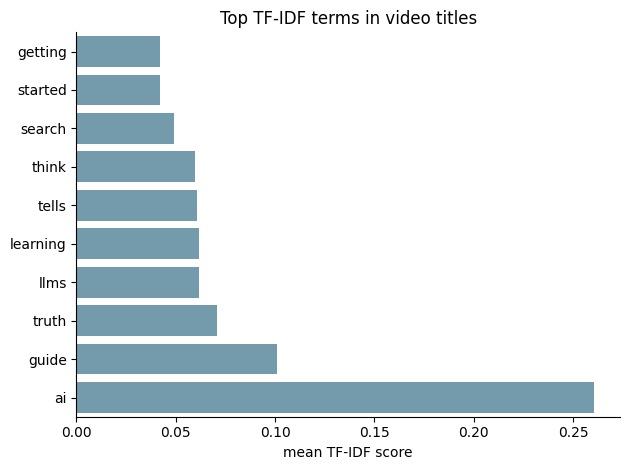

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv("youtube_videos.csv")

vectorizer = TfidfVectorizer(max_features=10, stop_words="english")
tfidf_matrix = vectorizer.fit_transform(df["title"])

terms = vectorizer.get_feature_names_out()
mean_scores = tfidf_matrix.toarray().mean(axis=0)

tfidf_df = pd.DataFrame({
    "term": terms,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=True)

sns.barplot(data=tfidf_df,
            x="mean_tfidf",
            y="term",
            color="#6a9fb5")

plt.title("Top TF-IDF terms in video titles")
plt.xlabel("mean TF-IDF score")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

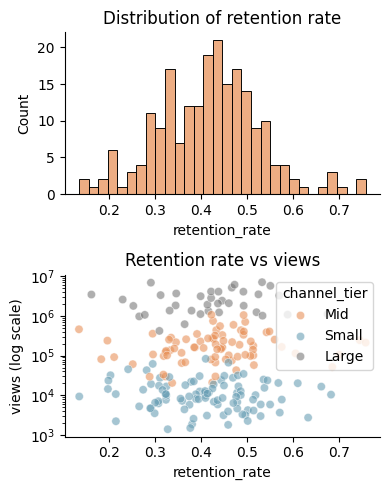

In [41]:
df = pd.read_csv("youtube_videos.csv")

df["duration_minutes"] = df["duration_seconds"] / 60

df["retention_rate"] = (
    df["watch_time_minutes"] /
    (df["views"] * df["duration_minutes"])
).clip(0, 1)

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["retention_rate"],
             bins=30,
             color="#e8925a",
             ax=axes[0])
axes[0].set_title("Distribution of retention rate")
axes[0].set_xlabel("retention_rate")

sns.scatterplot(data=df,
                x="retention_rate",
                y="views",
                hue="channel_tier",
                palette={"Small": "#6a9fb5",
                         "Mid": "#e8925a",
                         "Large": "#7a7a7a"},
                alpha=0.6,
                ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Retention rate vs views")
axes[1].set_xlabel("retention_rate")
axes[1].set_ylabel("views (log scale)")

sns.despine()
plt.tight_layout()
plt.show()

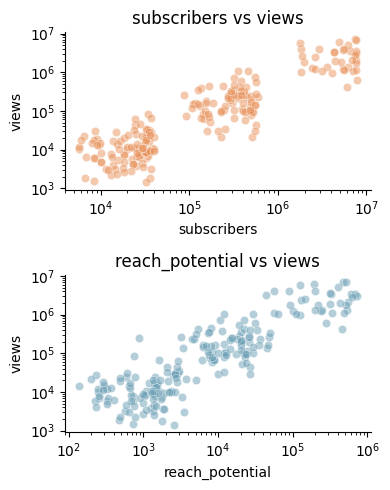

In [42]:
df = pd.read_csv("youtube_videos.csv")

df["reach_potential"] = (
    df["subscribers"] * df["click_through_rate"]
)

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.scatterplot(data=df,
                x="subscribers",
                y="views",
                color="#e8925a",
                alpha=0.5,
                ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("subscribers vs views")

sns.scatterplot(data=df,
                x="reach_potential",
                y="views",
                color="#6a9fb5",
                alpha=0.5,
                ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("reach_potential vs views")

sns.despine()
plt.tight_layout()
plt.show()

In [43]:
import json

df = pd.read_csv("youtube_videos.csv")

df["hashtags"] = df["hashtags"].apply(json.loads)

from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
hashtag_encoded = pd.DataFrame(
    mlb.fit_transform(df["hashtags"]),
    columns=mlb.classes_,
    index=df.index
)

result = pd.concat([df[["video_id"]], hashtag_encoded], axis=1)
print(result.head(4).to_string(index=False))

video_id  ai  chatgpt  comedy  datascience  deeplearning  explained  gaming  howto  llm  machinelearning  music  news  python  review  shorts  tech  trending  tutorial  viral  vlog
vid_0000   1        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         1         1      0     0
vid_0001   0        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         0         1      0     0
vid_0002   0        0       0            0             0          1       0      0    0                0      0     0       0       0       0     0         0         0      0     0
vid_0003   0        0       0            0             0          1       1      0    0                0      0     0       0       0       0     1         1         0      0     0
